# SEGMENTATION with SlimSAM

In [ ]:
from transformers import pipeline
from PIL import Image
import matplotlib.pyplot as plt

In [ ]:


# Load the Segmentation model
seg_pipe = pipeline("mask-generation", model="Zigeng/SlimSAM-uniform-77")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/38.9M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cuda:0


In [ ]:
!wget https://drive.google.com/uc?id=1Yox-XWM-PY9vFtDdzB_y_U3SK2paewwe -O kitty.jpg
!wget https://drive.google.com/uc?id=11OGaL-2yqTaHAdCMIiVpsZi0pE5SuQDG -O cows.png
!wget https://drive.google.com/uc?id=18eQeCLX-5KuxtX5M6cG-7izXVWDLPKQr -O kitties.jpg


--2025-11-05 08:29:23--  https://drive.google.com/uc?id=1Yox-XWM-PY9vFtDdzB_y_U3SK2paewwe
Resolving drive.google.com (drive.google.com)... 142.251.12.139, 142.251.12.102, 142.251.12.100, ...
Connecting to drive.google.com (drive.google.com)|142.251.12.139|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1Yox-XWM-PY9vFtDdzB_y_U3SK2paewwe [following]
--2025-11-05 08:29:24--  https://drive.usercontent.google.com/download?id=1Yox-XWM-PY9vFtDdzB_y_U3SK2paewwe
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.250.4.132, 2404:6800:4003:c06::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.250.4.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 79570 (78K) [image/jpeg]
Saving to: ‘kitty.jpg’

kitty.jpg           100%[===================>]  77.71K  --.-KB/s    in 0s      

2025-11-05 08:29:26 (179 MB/s) - ‘kitty.jpg’ saved [795

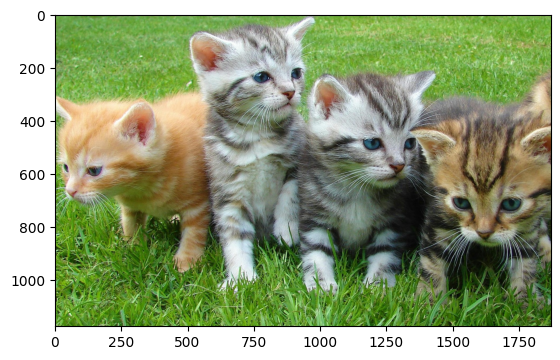

In [ ]:

image = Image.open("kitties.jpg")
plt.imshow(image)
plt.show()


In [ ]:
segmentation_output = seg_pipe(image)

In [ ]:
segmentation_output.keys()

dict_keys(['masks', 'scores'])

In [ ]:
len(segmentation_output['masks'])

16

In [ ]:
print(segmentation_output['masks'][0])

[[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]


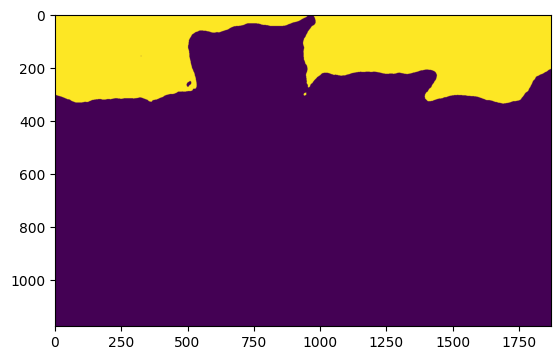

In [ ]:
plt.imshow(segmentation_output['masks'][0])
plt.show()

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

In [ ]:
def show_pipe_masks_on_image(raw_image, outputs):
    plt.imshow(np.array(raw_image))
    ax = plt.gca()
    for mask in outputs["masks"]:
        show_mask(mask, ax=ax, random_color=True)
    plt.axis("off")
    plt.show()

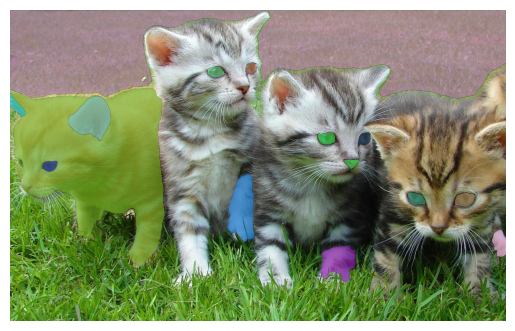

In [ ]:
# Call the function to visualize segmentation
show_pipe_masks_on_image(image, segmentation_output)

##segment on single point
* Mask Ambiguity -
This number is set to 3 since the SAM team considers 3 masks generally cover most of the scenarios (whole body, part, sub-part).

In [ ]:
from transformers import SamModel, SamProcessor

model = SamModel.from_pretrained("Zigeng/SlimSAM-uniform-77")

processor = SamProcessor.from_pretrained("Zigeng/SlimSAM-uniform-77")

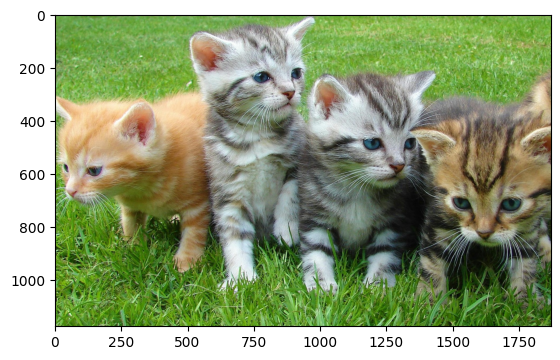

In [ ]:
plt.imshow(image)
plt.show()

In [ ]:
# Init input_points
input_points = [[[250, 600]]]

# Load input_points to preprocess
inputs = processor(image,
                 input_points=input_points,
                 return_tensors="pt")

In [ ]:
import torch

with torch.no_grad():
    outputs = model(**inputs)

predicted_masks = processor.image_processor.post_process_masks(
    outputs.pred_masks,
    inputs["original_sizes"],
    inputs["reshaped_input_sizes"]
)

In [ ]:
print(predicted_masks[0].shape)

torch.Size([1, 3, 1174, 1871])


These IoU scores denote the confidence score SAM has for each predicted mask to be “correct”

In [ ]:
outputs.iou_scores

tensor([[[0.7624, 0.9580, 0.9394]]])

In [ ]:
len(predicted_masks[0][0,:])

3

In [ ]:
def show_mask_on_image(raw_image, mask):
    if not isinstance(mask, torch.Tensor):
        mask = torch.Tensor(mask)
    if len(mask.shape) == 4:
        mask = mask.squeeze()
    print(mask.shape)
    fig, axes = plt.subplots(1, 1, figsize=(15, 15))
    mask = mask.cpu().detach()
    axes.imshow(np.array(raw_image))
    show_mask(mask, axes)
    axes.axis("off")
    plt.show()

torch.Size([1, 1174, 1871])


/tmp/ipython-input-1669784776.py:11: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)


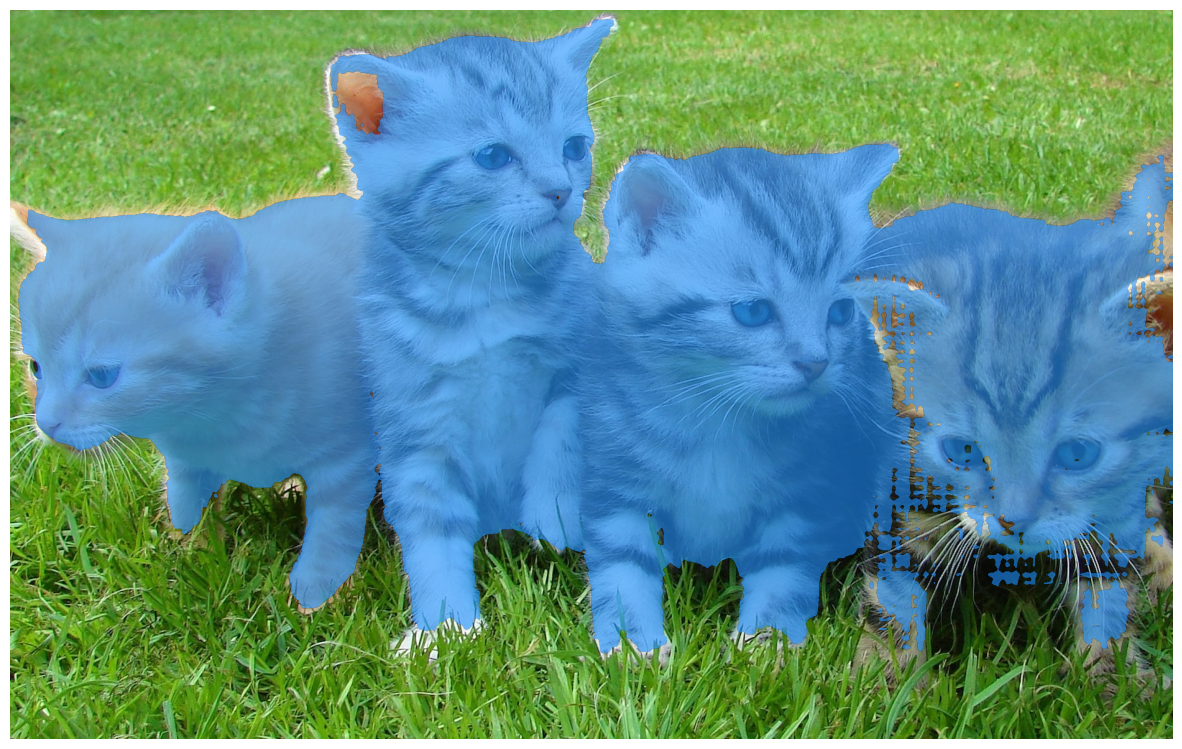

torch.Size([1, 1174, 1871])


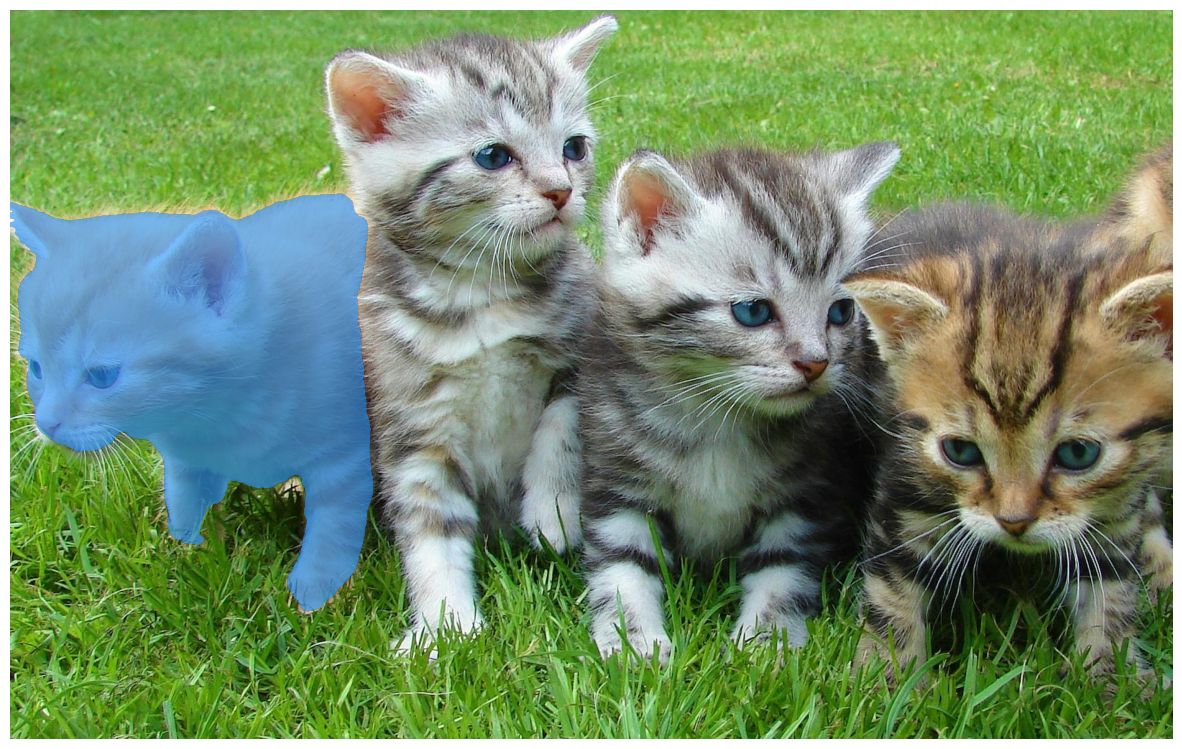

torch.Size([1, 1174, 1871])


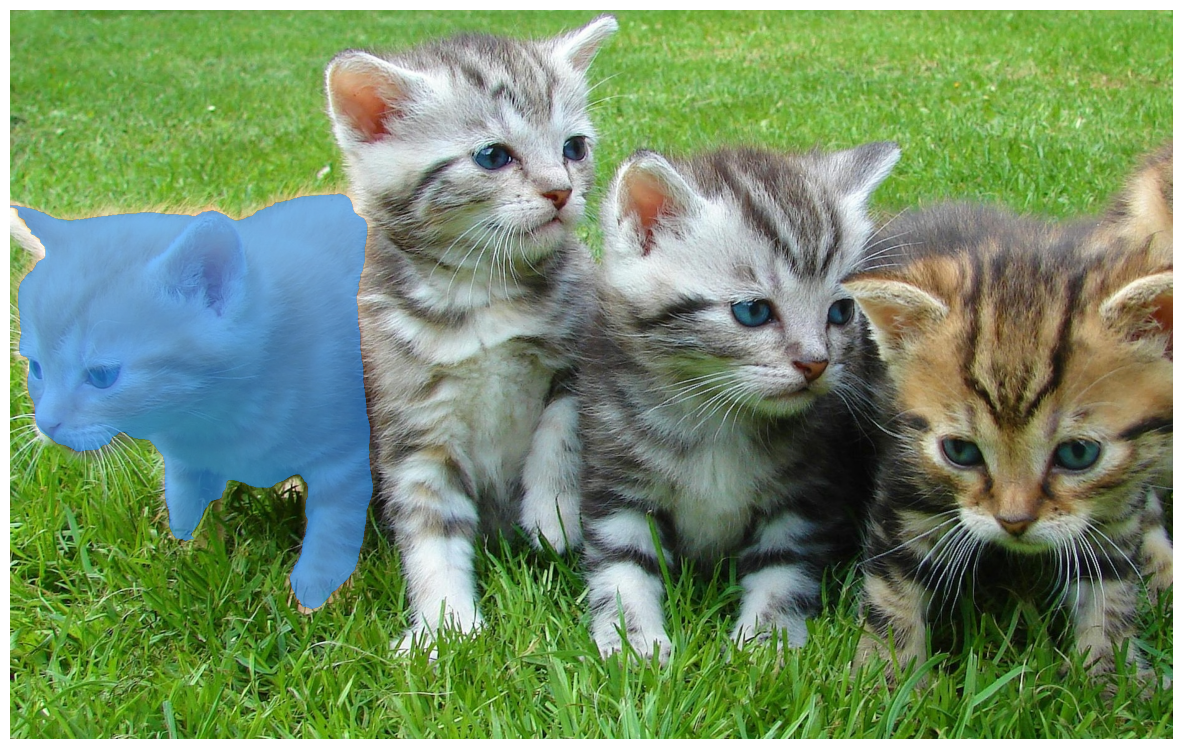

In [ ]:
for i in range(len(predicted_masks[0][0,:])):
    show_mask_on_image(image, predicted_masks[0][:, i])

In [ ]:
print((3*3*128+1)*128)

147584
